Extract Dataset

In [ ]:
import zipfile
import os

zip_path = "/content/FruitinAmazon.zip"
extract_path = "/content/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Extraction Done!")


print(os.listdir("/content"))
print(os.listdir("/content/FruitinAmazon"))

✅ Extraction Done!
['.config', 'FruitinAmazon', 'FruitinAmazon.zip', 'sample_data']
['train', 'test']


Task 1: Data Understanding and Visualization

1.1 Load and Visualize Images

Classes: ['graviola', 'cupuacu', 'tucuma', 'pupunha', 'acai', 'guarana']


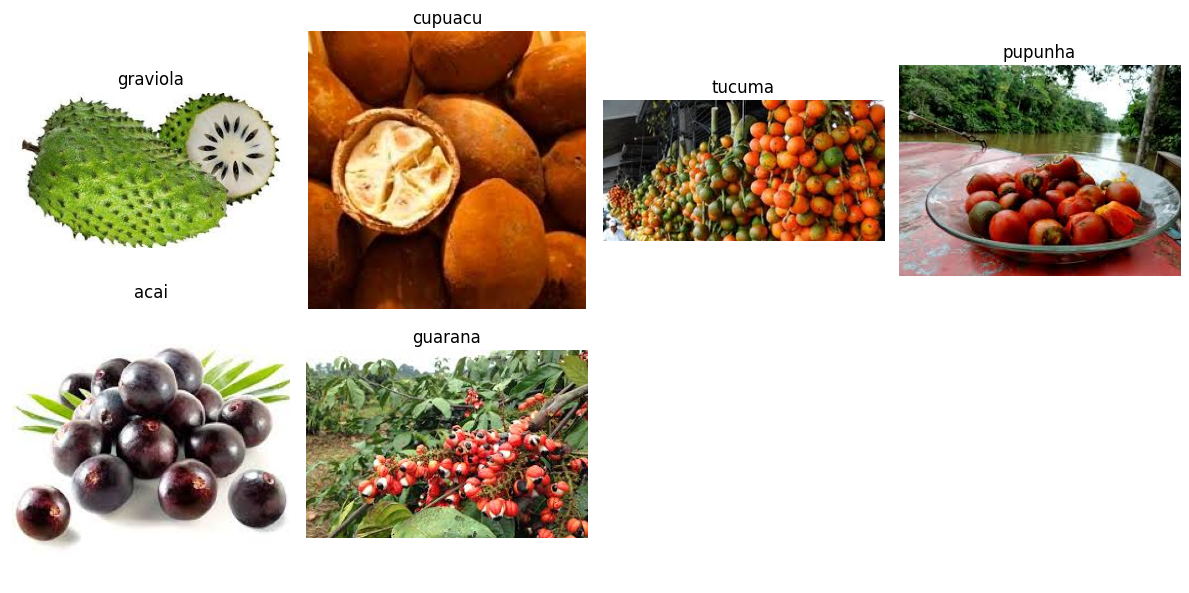

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

train_dir = "/content/FruitinAmazon/train"


class_names = os.listdir(train_dir)
print("Classes:", class_names)

images = []
labels = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        img_name = random.choice(os.listdir(class_path))
        img_path = os.path.join(class_path, img_name)

        img = Image.open(img_path)
        images.append(img)
        labels.append(class_name)

plt.figure(figsize=(12,6))

for i in range(len(images)):
    plt.subplot(2, len(images)//2 + 1, i+1)
    plt.imshow(images[i])
    plt.title(labels[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

1.2 Check for Corrupted Images

In [ ]:
from PIL import Image

corrupted = []

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            try:
                img = Image.open(img_path)
                img.verify()
            except:
                print("Removed corrupted image:", img_path)
                corrupted.append(img_path)
                os.remove(img_path)

if len(corrupted) == 0:
    print("No corrupted images found.")

No corrupted images found.


Task 2: Loading and Preprocessing Image Data



In [ ]:
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2


train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)


class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)


rescale = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


Task 3: Implement CNN Model



In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([

    layers.Input(shape=(128,128,3)),

    # Convolution Layer 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    # Convolution Layer 2
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Flatten Layer
    layers.Flatten(),

    # Fully Connected Layers
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),

    # Output Layer
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

Task 4: Compile the Model



In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Task 5: Train the Model



In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(monitor='val_loss', patience=10)

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_accuracy',
    save_best_only=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.1655 - loss: 2.0160

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 583ms/step - accuracy: 0.1528 - loss: 2.2450 - val_accuracy: 0.8333 - val_loss: 1.0273
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 571ms/step - accuracy: 0.2083 - loss: 2.3744 - val_accuracy: 0.0000e+00 - val_loss: 1.5833
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 645ms/step - accuracy: 0.2361 - loss: 1.7157 - val_accuracy: 0.1111 - val_loss: 1.6313
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 392ms/step - accuracy: 0.3056 - loss: 1.5988 - val_accuracy: 0.1111 - val_loss: 1.6363
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 423ms/step - accuracy: 0.4583 - loss: 1.4311 - val_accuracy: 0.2222 - val_loss: 1.5235
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 403ms/step - accuracy: 0.5139 - loss: 1.2007 - val_accuracy: 0.6111 - val_loss: 1.2956
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 410ms/step - accuracy: 0.7639 - loss: 0.9254 - val_accuracy: 0.7222 - val_loss: 1.0760
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 431ms/step - accuracy: 0.8611 - loss: 0.6957 - val_accuracy: 0.7778 - val_loss:

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 464ms/step - accuracy: 0.8750 - loss: 0.5261 - val_accuracy: 0.8889 - val_loss: 0.5763
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 946ms/step - accuracy: 0.9444 - loss: 0.3553 - val_accuracy: 0.7222 - val_loss: 0.6942
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 573ms/step - accuracy: 0.9167 - loss: 0.3223 - val_accuracy: 0.7778 - val_loss: 0.6144
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 530ms/step - accuracy: 0.9583 - loss: 0.1753 - val_accuracy: 0.8889 - val_loss: 0.4645
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 513ms/step - accuracy: 0.9306 - loss: 0.2246 - val_accuracy: 0.8333 - val_loss: 0.5595
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 400ms/step - accuracy: 0.9861 - loss: 0.0970 - val_accuracy: 0.8889 - val_loss: 0.5104
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 402ms/step - accuracy: 0.9722 - loss: 0.1028 - val_accuracy: 0.8889 - val_loss: 0.3288
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 428ms/step - accuracy: 1.0000 - loss: 0.0539 - val_accuracy: 0.8889 - val_lo

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 455ms/step - accuracy: 1.0000 - loss: 0.0213 - val_accuracy: 0.9444 - val_loss: 0.2688
Epoch 23/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 414ms/step - accuracy: 1.0000 - loss: 0.0237 - val_accuracy: 0.8889 - val_loss: 0.2178
Epoch 24/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 402ms/step - accuracy: 1.0000 - loss: 0.0152 - val_accuracy: 0.8333 - val_loss: 0.3183
Epoch 25/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 407ms/step - accuracy: 1.0000 - loss: 0.0094 - val_accuracy: 0.8333 - val_loss: 0.4393
Epoch 26/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 724ms/step - accuracy: 1.0000 - loss: 0.0050 - val_accuracy: 0.8333 - val_loss: 0.5636
Epoch 27/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 478ms/step - accuracy: 1.0000 - loss: 0.0042 - val_accuracy: 0.8333 - val_loss: 0.6461


Task 6: Evaluate the Model



In [ ]:
loss, acc = model.evaluate(val_ds)
print("Validation Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.8333 - loss: 0.6461
Validation Accuracy: 0.8333333134651184


Task 7: Save and Load Model
7.1 Save Model

In [ ]:
model.save("final_model.keras")

7.2 Load Model

In [ ]:
from tensorflow.keras.models import load_model

loaded_model = load_model("final_model.keras")

loss, acc = loaded_model.evaluate(val_ds)
print("Loaded Model Accuracy:", acc)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.8333 - loss: 0.6461
Loaded Model Accuracy: 0.8333333134651184


Task 8: Predictions and Classification Report

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    pred_labels = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(pred_labels)

print(classification_report(y_true, y_pred, zero_division=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0
           4       1.00      0.67      0.80         3
           5       1.00      0.87      0.93        15

    accuracy                           0.83        18
   macro avg       0.40      0.31      0.35        18
weighted avg       1.00      0.83      0.91        18



Task 9: Visualization of Performance

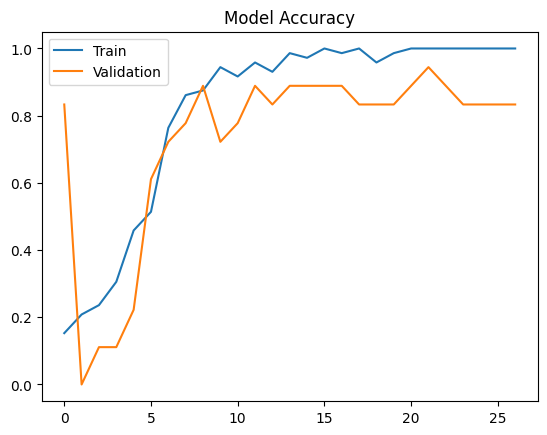

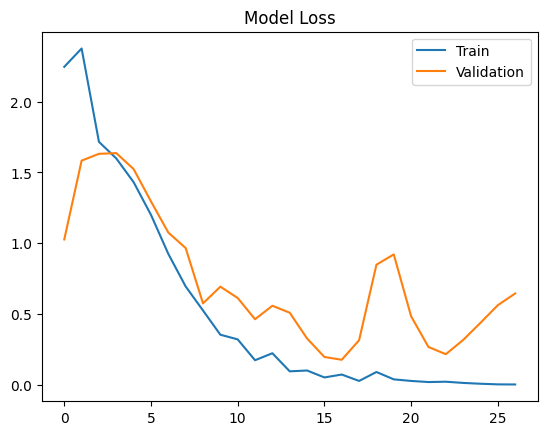

In [ ]:
import matplotlib.pyplot as plt

# Accuracy Graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

# Loss Graph
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.legend(["Train", "Validation"])
plt.show()